In [1]:
import numpy as np


def read_latency_data(file, ignore):
    data = {"end_to_end": [], "service": []}
    with open(file, "r") as file:
        for line in file.readlines():
            span, latency = line.strip().split(",")
            assert span in data.keys()
            data[span].append(int(latency))
    for span in data.keys():
        n_ignore = int(len(data[span]) * ignore)
        data[span] = data[span][n_ignore:]
    return data 


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail

In [2]:
rps_values = list(range(100, 2001, 100))
e2e_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}
svc_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}

pctl = 99
for rps in rps_values:
    e2e_data["rps"].append(rps)
    svc_data["rps"].append(rps)

    file = f"r{rps}-fcfs.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["fcfs"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["fcfs"].append(get_pctl(data["service"], pctl))

    file = f"r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["masa"].append(get_pctl(data["service"], pctl))

print(e2e_data)
print()
print(svc_data)

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [50239, 54004, 58102, 62879, 67938, 73675, 81273, 87750, 96629, 108274, 119911, 136809, 156631, 183623, 224654, 278432, 378278, 578472, 929258, 954979], 'masa': [50220, 53425, 56564, 60777, 64316, 68665, 74845, 78863, 85394, 93455, 102409, 116049, 128411, 149713, 182666, 226234, 309905, 474708, 731387, 719584]}

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [13131, 13658, 13729, 14228, 14813, 16069, 17674, 19261, 21722, 24012, 27708, 30346, 37296, 46664, 53730, 68503, 92180, 147031, 263674, 262830], 'masa': [13156, 13667, 13950, 14298, 14963, 16235, 18804, 20334, 23569, 27735, 32723, 39194, 44931, 54500, 66063, 86619, 113382, 172993, 289695, 277955]}


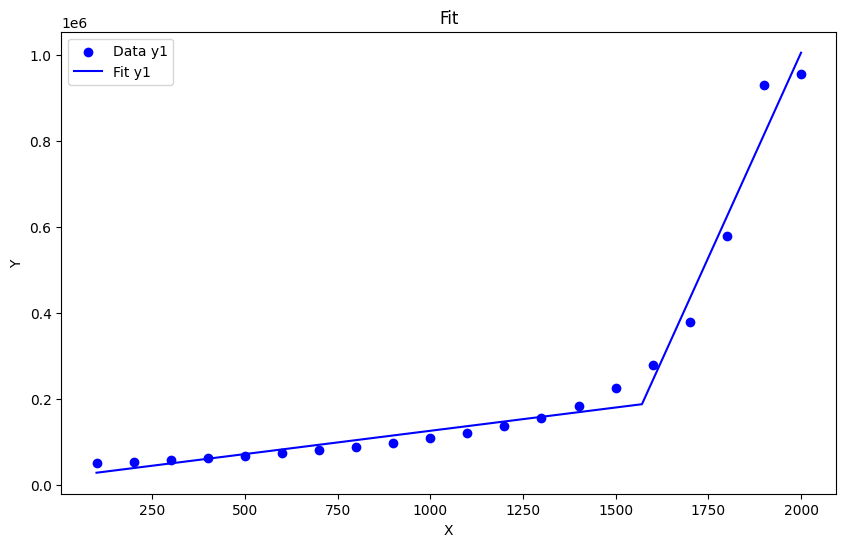

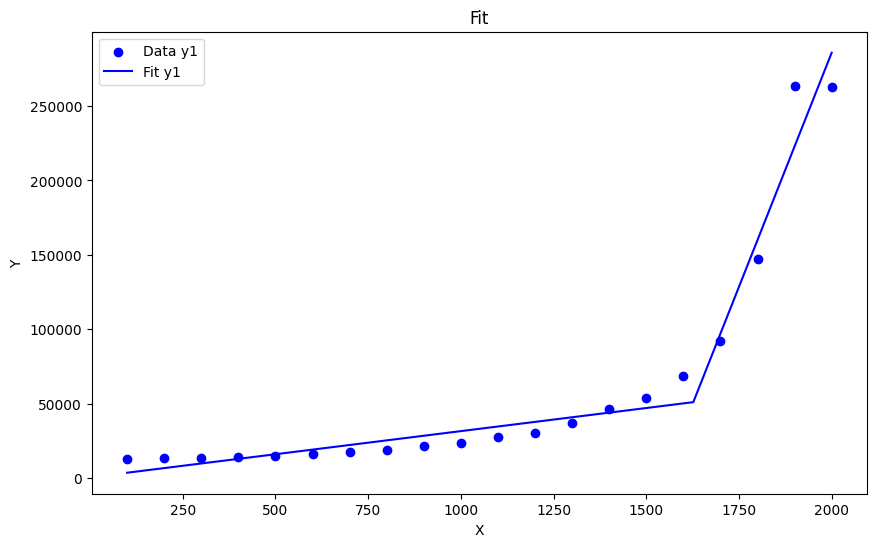

40000 207 4000 108 1.92
45000 253 4500 124 2.044
50000 299 5000 140 2.139
55000 345 5500 156 2.214
60000 392 6000 172 2.276
65000 438 6500 188 2.327
70000 484 7000 204 2.369
75000 530 7500 220 2.406
80000 577 8000 237 2.438
85000 623 8500 253 2.465
90000 669 9000 269 2.489
95000 715 9500 285 2.511
100000 762 10000 301 2.53
105000 808 10500 317 2.547
110000 854 11000 333 2.563
115000 900 11500 349 2.577
120000 947 12000 365 2.59
125000 993 12500 382 2.602
130000 1039 13000 398 2.613


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pwlf
from scipy.optimize import fsolve


def plot(data):
    n_points = len(data["rps"])
    x = np.array(data["rps"][:n_points])
    y1 = np.array(data["fcfs"][:n_points])
    # y2 = np.array(data["masa"][:n_points])

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y1, color="blue", label="Data y1")
    # plt.scatter(x, y2, color="green", label="Data y2")

    fit = pwlf.PiecewiseLinFit(x, y1)
    fit.fit(2)
    x_hat = np.linspace(min(x), max(x), num=10000)
    y_hat = fit.predict(x_hat)
    plt.plot(x_hat, y_hat, color="blue", label="Fit y1")

    plt.title("Fit")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

    return fit


def solve(p, target):
    return fsolve(lambda x: p(x) - target, 1000)


e2e_fit = plot(e2e_data)
svc_fit = plot(svc_data)

slos = [
    40000,
    45000,
    50000,
    55000,
    60000,
    65000,
    70000,
    75000,
    80000,
    85000,
    90000,
    95000,
    100000,
    105000,
    110000,
    115000,
    120000,
    125000,
    130000,
]
for slo in slos:
    x1 = solve(e2e_fit.predict, slo)[0]
    x2 = solve(svc_fit.predict, slo / 10)[0]
    print(
        round(slo),
        round(x1),
        round(slo / 10),
        round(x2),
        round(x1 / x2, 3),
    )